In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive'))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
print(os.listdir('/content/drive/MyDrive'))

['InShot_20220711_162617654.jpg', 'Picsart_22-07-11_16-22-22-494.jpg', 'Picsart_22-07-11_16-16-29-285.jpg', 'IMG_20220709_132441-01.jpeg', 'IMG_20220709_132845.jpg', 'IMG_20220709_133613.jpg', 'IMG_20220709_132501.jpg', 'IMG_20220709_132441.jpg', 'IMG_20220709_133248.jpg', 'IMG_20220709_133246.jpg', 'IMG_20220709_132840.jpg', 'IMG_20220709_132845-01.jpeg', 'Snapchat-543861565.jpg', 'Snapchat-798628779.jpg', 'Snapchat-1262108215.jpg', 'Snapchat-1785626689.jpg', 'Snapchat-2004868768.jpg', 'Snapchat-743540910.jpg', 'Snapchat-92534935.jpg', 'Snapchat-1849447510.jpg', 'Snapchat-1966661523.jpg', 'Snapchat-1840824236.jpg', 'Snapchat-1236190591.jpg', 'Snapchat-1923463358.jpg', 'Snapchat-82259547.jpg', 'Snapchat-1229759147.jpg', 'Snapchat-299493398.jpg', 'Snapchat-1232005825.jpg', 'Snapchat-1421176290.jpg', 'Snapchat-475771131.jpg', 'Snapchat-919923933.jpg', 'Snapchat-1575571611.jpg', 'Snapchat-191190098.jpg', 'Snapchat-1260911402.jpg', 'Snapchat-1503810509.jpg', 'Snapchat-2001028701.jpg', 'Sna

In [ ]:
path='/content/drive/MyDrive/Tomato_plant_disease_prediction/dataset'
print(os.listdir(path))

['Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight']


In [ ]:
for folder in os.listdir(path):
  folder_path=os.path.join(path,folder)

  if os.path.isdir(folder_path):
    count=len(os.listdir(folder_path))
    print(folder,":",count)

Tomato___healthy : 1591
Tomato___Early_blight : 999
Tomato___Late_blight : 1909


In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(123)
np.random.seed(123)
random.seed(123)


In [ ]:
import tensorflow as tf
base_path='/content/drive/MyDrive/Tomato_plant_disease_prediction/dataset'

train_ds=tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 4499 files belonging to 3 classes.
Using 3150 files for training.


In [ ]:
remaining_ds=tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 4499 files belonging to 3 classes.
Using 1349 files for validation.


In [ ]:
total_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
print("Total batches:", total_batches)

Total batches: 43


In [ ]:
val_ds = remaining_ds.take(21)

test_ds = remaining_ds.skip(21)

In [ ]:
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 99
Validation batches: 21
Test batches: 22


In [ ]:
class_names=train_ds.class_names
class_names

['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']

In [ ]:
for images,labels in train_ds.take(1):
  print("Images shape:",images.shape)
  print("Labels shape:",labels.shape)
  print(labels.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
[0 0 1 0 2 1 2 1 2 2 0 1 1 2 2 2 1 2 1 0 2 0 1 2 1 2 0 0 1 1 2 0]


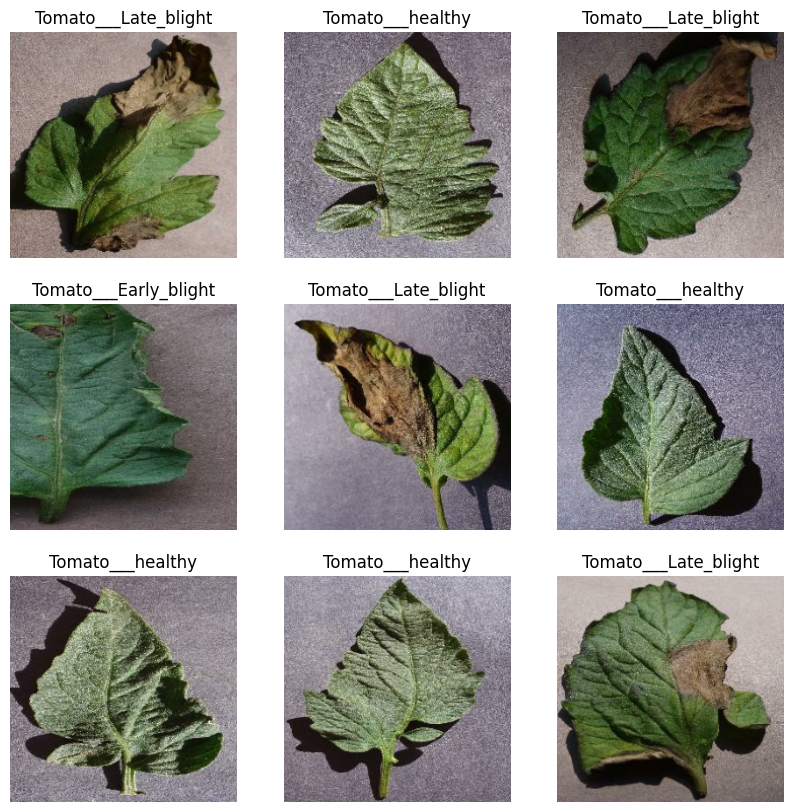

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    tf.keras.layers.Conv2D(32,(3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(3,activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
  optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"]
)

In [ ]:
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.5032 - loss: 35.4490 - val_accuracy: 0.5357 - val_loss: 0.9534
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6397 - loss: 0.8278 - val_accuracy: 0.5357 - val_loss: 0.9445
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7289 - loss: 0.6318 - val_accuracy: 0.5863 - val_loss: 0.9987
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.7952 - loss: 0.5332 - val_accuracy: 0.5952 - val_loss: 1.3663
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.8683 - loss: 0.3534 - val_accuracy: 0.6815 - val_loss: 1.3717
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8644 - loss: 0.3675 - val_accuracy: 0.6979 - val_loss: 1.3326
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.8876 - loss: 0.3263 - val_accuracy: 0.7232 - val_loss: 1.0849
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8981 - loss: 0.2679 - val_accuracy: 0.733

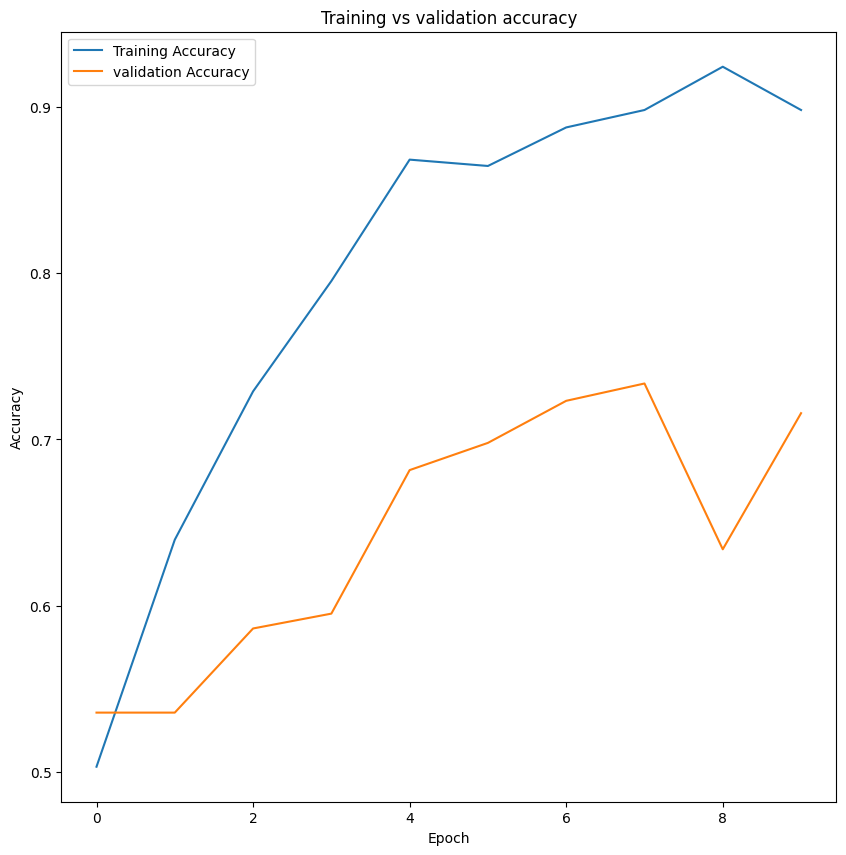

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title('Training vs validation accuracy')

plt.legend()
plt.show()

In [ ]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
model_aug=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(3,activation="softmax")
])

In [ ]:
model_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model_aug.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_aug=model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.4717 - loss: 30.4060 - val_accuracy: 0.5402 - val_loss: 0.9636
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.5435 - loss: 0.9492 - val_accuracy: 0.6667 - val_loss: 0.8913
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.5352 - loss: 0.9747 - val_accuracy: 0.5670 - val_loss: 1.2830
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5692 - loss: 0.9160 - val_accuracy: 0.6369 - val_loss: 1.0322
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6587 - loss: 0.7943 - val_accuracy: 0.7232 - val_loss: 0.6704
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.6343 - loss: 0.7880 - val_accuracy: 0.6875 - val_loss: 0.9035
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7248 - loss: 0.6387 - val_accuracy: 0.7470 - val_loss: 0.8088
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7844 - loss: 0.5256 - val_accuracy: 0.7753 -

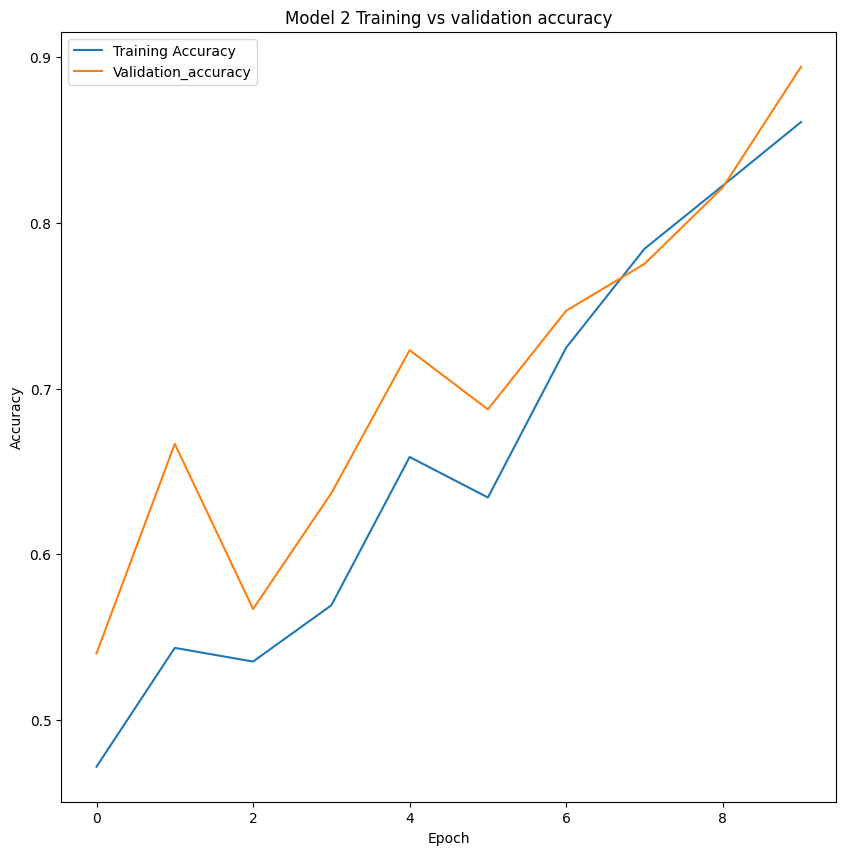

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))

plt.plot(history_aug.history["accuracy"],label="Training Accuracy")
plt.plot(history_aug.history["val_accuracy"],label="Validation_accuracy")

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 2 Training vs validation accuracy')

plt.legend()
plt.show()

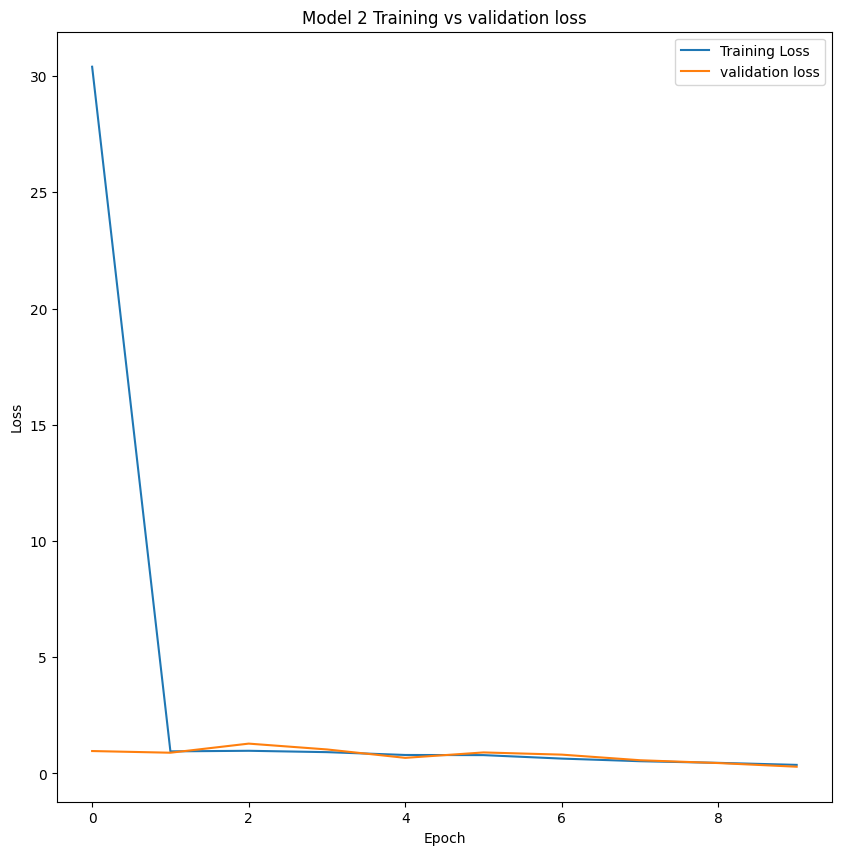

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(history_aug.history["loss"],label="Training Loss")
plt.plot(history_aug.history["val_loss"],label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Training vs validation loss")

plt.legend()
plt.show()

In [ ]:
model_3 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(3, activation="softmax")
])

In [ ]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
model_3.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_aug_early=model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.6041 - loss: 25.7010 - val_accuracy: 0.7545 - val_loss: 0.5404
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.6730 - loss: 0.7424 - val_accuracy: 0.6696 - val_loss: 0.7546
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.7302 - loss: 0.6121 - val_accuracy: 0.7783 - val_loss: 1.1341
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7981 - loss: 0.4586 - val_accuracy: 0.7738 - val_loss: 0.7482


In [ ]:
print(early_stopping)
print(type(early_stopping))
print(early_stopping.patience)
print(early_stopping.monitor)
print(early_stopping.restore_best_weights)

<class 'keras.src.callbacks.early_stopping.EarlyStopping'>
3
val_loss
True


In [ ]:
import numpy as np
y_true=[]
y_pred=[]

for images, labels in val_ds:
    predictions = model_aug.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
cm=confusion_matrix(y_true,y_pred)
print(cm)

[[123  29   5]
 [ 24 251  13]
 [  1   4 222]]


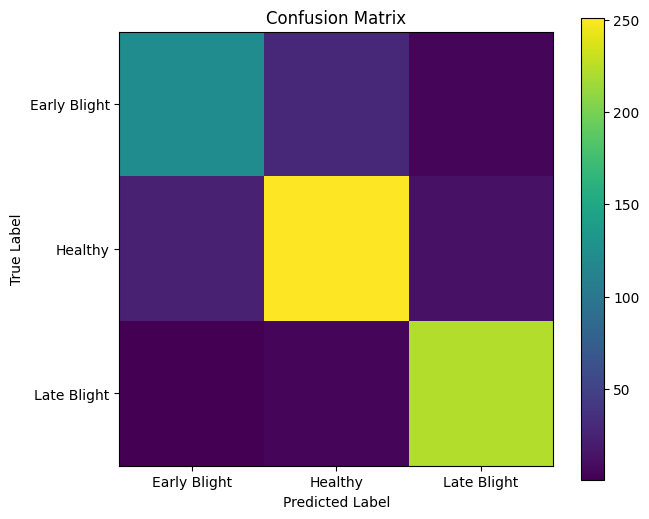

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0, 1, 2],
    ["Early Blight", "Healthy", "Late Blight"]
)

plt.yticks(
    [0, 1, 2],
    ["Early Blight", "Healthy", "Late Blight"]
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=["Early Blight","Healthy","Late Blight"]
))

              precision    recall  f1-score   support

Early Blight       0.83      0.78      0.81       157
     Healthy       0.88      0.87      0.88       288
 Late Blight       0.93      0.98      0.95       227

    accuracy                           0.89       672
   macro avg       0.88      0.88      0.88       672
weighted avg       0.89      0.89      0.89       672



In [ ]:
test_loss,test_accuracy=model_aug.evaluate(test_ds)

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8715 - loss: 0.3055
Test Loss: 0.3054717481136322
Test Accuracy: 0.8714918494224548


In [ ]:
import numpy as np

y_true=[]
y_pred=[]

for images, labels in test_ds:
    predictions=model_aug.predict(images,verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions,axis=1))


y_true=np.array(y_true)
y_pred=np.array(y_pred)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=["Early Blight","Late Blight","Healthy"]
))


              precision    recall  f1-score   support

Early Blight       0.76      0.69      0.72       146
 Late Blight       0.84      0.82      0.83       280
     Healthy       0.92      0.99      0.96       251

    accuracy                           0.86       677
   macro avg       0.84      0.84      0.84       677
weighted avg       0.85      0.86      0.86       677



[[101  41   4]
 [ 32 231  17]
 [  0   2 249]]


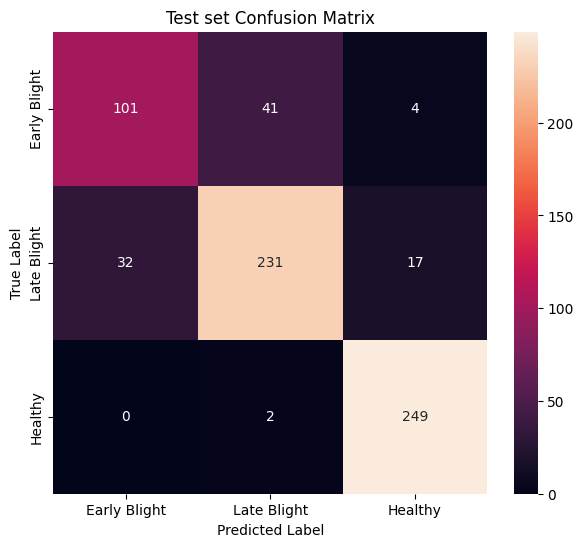

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm =confusion_matrix(y_true,y_pred)
print(cm)
plt.figure(figsize=(7,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["Early Blight","Late Blight","Healthy"],
            yticklabels=["Early Blight","Late Blight","Healthy"])


plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Test set Confusion Matrix")
plt.show()

In [ ]:
model_aug.save("Tomato_disease_prediction_model.keras")

In [ ]:
model_aug.save("/content/drive/MyDrive/Tomato_plant_disease_prediction/tomato_disease_model.keras")